Please upload an image file:


Saving poster-2.png to poster-2.png
Enter filter size (odd integer, e.g., 3, 5, 7) [default: 5]: 7
Enter sigma for Gaussian filter (float > 0) [default: 1.0]: 0.8

Select Padding Method:
  1. Zero Padding (constant=0)
  2. Replicate / Clamp (edge replicate)
  3. Reflect (mirror without repeating edge pixel)
Enter choice (1/2/3) [default: 1]: 2


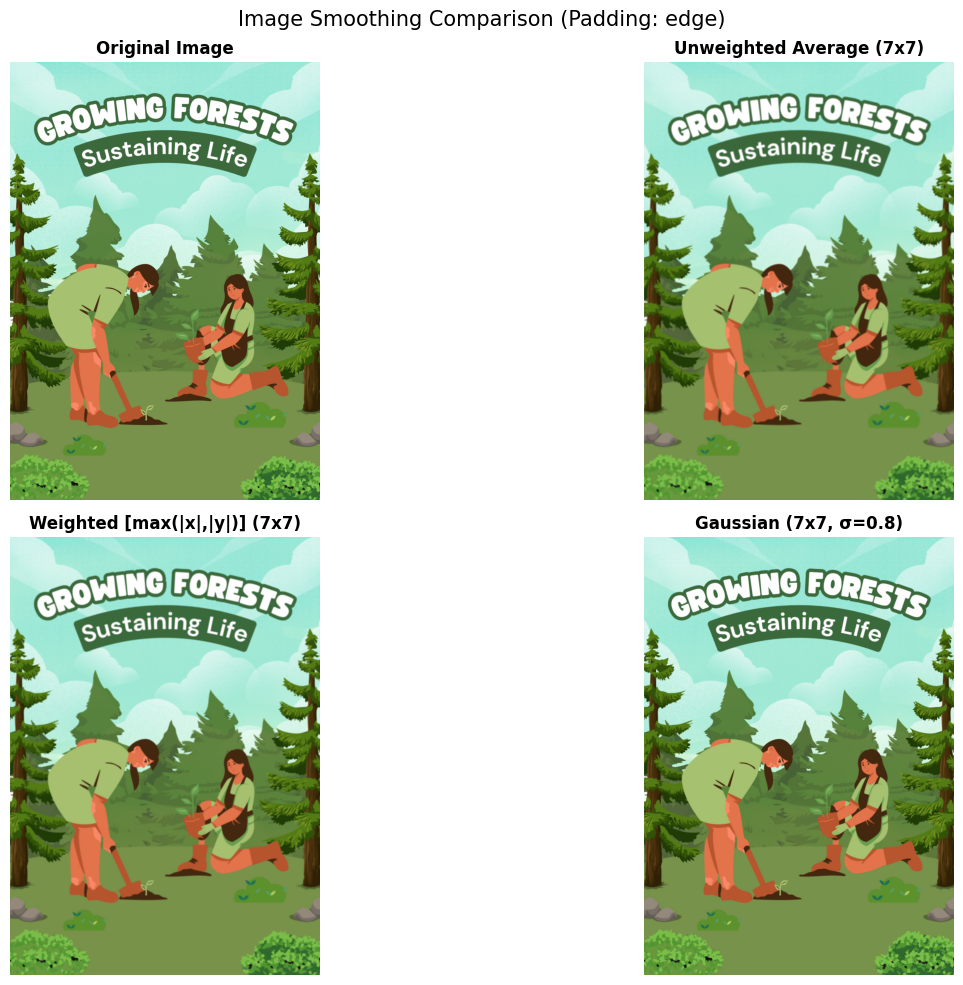

In [1]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


print("Please upload an image file:")
uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded. Please run the cell again and choose an image.")

filename = next(iter(uploaded))
image_bytes = uploaded[filename]


img_array = np.frombuffer(image_bytes, np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



def get_user_inputs():
    while True:
        try:
            k_input = input("Enter filter size (odd integer, e.g., 3, 5, 7) [default: 5]: ").strip()
            k = int(k_input) if k_input else 5
            if k > 0 and k % 2 == 1:
                break
            print("Filter size must be an odd, positive integer.")
        except ValueError:
            print("Invalid input. Please enter an integer.")


    while True:
        try:
            sigma_input = input("Enter sigma for Gaussian filter (float > 0) [default: 1.0]: ").strip()
            sigma = float(sigma_input) if sigma_input else 1.0
            if sigma > 0:
                break
            print("Sigma must be greater than 0.")
        except ValueError:
            print("Invalid input. Please enter a valid number.")


    print("\nSelect Padding Method:")
    print("  1. Zero Padding (constant=0)")
    print("  2. Replicate / Clamp (edge replicate)")
    print("  3. Reflect (mirror without repeating edge pixel)")

    pad_choice = input("Enter choice (1/2/3) [default: 1]: ").strip()
    pad_map = {
        '1': ('constant', {'constant_values': 0}),
        '2': ('edge', {}),
        '3': ('reflect', {})
    }
    pad_mode, pad_kwargs = pad_map.get(pad_choice, ('constant', {'constant_values': 0}))

    return k, sigma, pad_mode, pad_kwargs

k_size, sigma, pad_mode, pad_kwargs = get_user_inputs()


def create_box_kernel(k):
    """Un-weighted box averaging filter."""
    kernel = np.ones((k, k), dtype=np.float64)
    return kernel / np.sum(kernel)

def create_distance_weighted_kernel(k):
    """
    Weighted smoothing filter based on Chebyshev distance:
    h(x, y) = max(|x|, |y|) from the kernel center.
    Inverted so central pixels receive the highest weight:
    weight(x, y) = (r + 1) - max(|x|, |y|)
    """
    r = k // 2
    y, x = np.ogrid[-r:r+1, -r:r+1]
    dist = np.maximum(np.abs(x), np.abs(y))


    kernel = (r + 1) - dist
    return kernel.astype(np.float64) / np.sum(kernel)

def create_gaussian_kernel(k, sig):
    """2D Gaussian smoothing filter."""
    r = k // 2
    y, x = np.ogrid[-r:r+1, -r:r+1]
    kernel = np.exp(-(x**2 + y**2) / (2.0 * sig**2))
    return kernel / np.sum(kernel)


def apply_filter_2d(channel, kernel, pad_mode, pad_kwargs):
    """Applies a 2D kernel over a single 2D image channel with specified padding."""
    pad_h = kernel.shape[0] // 2
    pad_w = kernel.shape[1] // 2

    padded = np.pad(channel, ((pad_h, pad_h), (pad_w, pad_w)), mode=pad_mode, **pad_kwargs)
    out = np.zeros_like(channel, dtype=np.float64)

    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            out += kernel[i, j] * padded[i:i + channel.shape[0], j:j + channel.shape[1]]

    return np.clip(out, 0, 255).astype(np.uint8)

def filter_image(image, kernel, pad_mode, pad_kwargs):
    """Applies a filter across each color channel (RGB)."""
    channels = [apply_filter_2d(image[:, :, c], kernel, pad_mode, pad_kwargs) for c in range(3)]
    return np.stack(channels, axis=-1)


k_box = create_box_kernel(k_size)
k_weighted = create_distance_weighted_kernel(k_size)
k_gaussian = create_gaussian_kernel(k_size, sigma)

box_filtered = filter_image(img_rgb, k_box, pad_mode, pad_kwargs)
weighted_filtered = filter_image(img_rgb, k_weighted, pad_mode, pad_kwargs)
gaussian_filtered = filter_image(img_rgb, k_gaussian, pad_mode, pad_kwargs)



titles = [
    'Original Image',
    f'Unweighted Average ({k_size}x{k_size})',
    f'Weighted [max(|x|,|y|)] ({k_size}x{k_size})',
    f'Gaussian ({k_size}x{k_size}, σ={sigma})'
]
images = [img_rgb, box_filtered, weighted_filtered, gaussian_filtered]

plt.figure(figsize=(16, 10))
for idx, (im, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 2, idx + 1)
    plt.imshow(im)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle(f"Image Smoothing Comparison (Padding: {pad_mode})", fontsize=15, y=0.98)
plt.tight_layout()
plt.show()